<a href="https://colab.research.google.com/github/SanjayGanapathy/AETHER/blob/main/AETHER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AETHER**: an **A**nomaly **E**nsemble Framework for **T**rajectory **H**euristics & **E**xplainable **R**easoning

Migratory Ecology of the Common Kestrel (*Falco tinnunculus*)  
### Data‑Quality Assessment & Spatial Analysis  
*Author: Sanjay Ganapathy*


In [ ]:
import pandas as pd

df = pd.read_csv("data.csv")
display(df.head())
display(df.info())

/tmp/ipython-input-3-251111154.py:3: DtypeWarning: Columns (15,18,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data.csv")


,event-id,visible,timestamp,location-long,location-lat,gps:activity-count,external-temperature,gps:dop,gps:hdop,gps:satellite-count,...,sensor-type,individual-taxon-canonical-name,tag-local-identifier,individual-local-identifier,study-name,utm-easting,utm-northing,utm-zone,study-timezone,study-local-timestamp
0,29615547747,True,2023-04-28 10:06:54.000,-6.470255,37.427571,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723839.343781,4.145310e+06,29N,GMT+00:00,2023-04-28 10:06:54.000
1,29615547748,True,2023-04-28 10:26:55.000,-6.477722,37.429683,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723172.271891,4.145527e+06,29N,GMT+00:00,2023-04-28 10:26:55.000
2,29615547749,True,2023-04-28 10:28:55.000,-6.478029,37.429824,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723144.667806,4.145542e+06,29N,GMT+00:00,2023-04-28 10:28:55.000
3,29615547750,True,2023-04-28 10:31:10.000,-6.477894,37.429808,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723156.609110,4.145540e+06,29N,GMT+00:00,2023-04-28 10:31:10.000
4,29615547751,True,2023-04-28 10:32:54.000,-6.477960,37.429709,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723151.098516,4.145529e+06,29N,GMT+00:00,2023-04-28 10:32:54.000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2534898 entries, 0 to 2534897
Data columns (total 30 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   event-id                         int64  
 1   visible                          bool   
 2   timestamp                        object 
 3   location-long                    float64
 4   location-lat                     float64
 5   gps:activity-count               float64
 6   external-temperature             float64
 7   gps:dop                          float64
 8   gps:hdop                         float64
 9   gps:satellite-count              float64
 10  gps-time-to-fix                  float64
 11  ground-speed                     float64
 12  heading                          float64
 13  height-above-msl                 float64
 14  height-raw                       float64
 15  import-marked-outlier            object 
 16  gls:light-level                  float64
 17  location

None

In [ ]:
required_columns = ['location-lat', 'location-long']
if all(col in df.columns for col in required_columns):
    print(f"Columns '{required_columns[0]}' and '{required_columns[1]}' exist in the DataFrame.")
    print(f"Initial number of rows: {len(df)}")

    df.dropna(subset=required_columns, inplace=True)
    print(f"Number of rows after dropping missing lat/long: {len(df)}")

    if 'timestamp' in df.columns:
        df.dropna(subset=['timestamp'], inplace=True)
        print(f"Number of rows after dropping missing timestamp: {len(df)}")
    else:
        print("Warning: 'timestamp' column not found.")

    display(df.head())

else:
    print(f"Error: Required columns '{required_columns[0]}' and/or '{required_columns[1]}' not found in the DataFrame.")

Columns 'location-lat' and 'location-long' exist in the DataFrame.
Initial number of rows: 2534898
Number of rows after dropping missing lat/long: 2534898
Number of rows after dropping missing timestamp: 2534898


,event-id,visible,timestamp,location-long,location-lat,gps:activity-count,external-temperature,gps:dop,gps:hdop,gps:satellite-count,...,sensor-type,individual-taxon-canonical-name,tag-local-identifier,individual-local-identifier,study-name,utm-easting,utm-northing,utm-zone,study-timezone,study-local-timestamp
0,29615547747,True,2023-04-28 10:06:54.000,-6.470255,37.427571,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723839.343781,4.145310e+06,29N,GMT+00:00,2023-04-28 10:06:54.000
1,29615547748,True,2023-04-28 10:26:55.000,-6.477722,37.429683,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723172.271891,4.145527e+06,29N,GMT+00:00,2023-04-28 10:26:55.000
2,29615547749,True,2023-04-28 10:28:55.000,-6.478029,37.429824,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723144.667806,4.145542e+06,29N,GMT+00:00,2023-04-28 10:28:55.000
3,29615547750,True,2023-04-28 10:31:10.000,-6.477894,37.429808,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723156.609110,4.145540e+06,29N,GMT+00:00,2023-04-28 10:31:10.000
4,29615547751,True,2023-04-28 10:32:54.000,-6.477960,37.429709,NaN,0.0,NaN,NaN,NaN,...,gps,Falco tinnunculus,1300000709,MX9208,(EBD) Common Kestrel (Falco tinnunculus) Spain...,723151.098516,4.145529e+06,29N,GMT+00:00,2023-04-28 10:32:54.000


In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 32.5 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


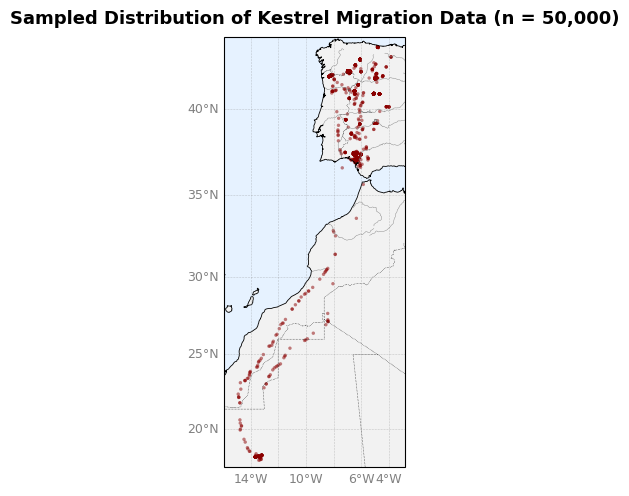

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# Sample the data
sample_df = df.sample(n=50000, random_state=55)
lats = sample_df['location-lat'].values
lons = sample_df['location-long'].values

# Create a wider landscape figure while keeping height
fig = plt.figure(figsize=(16, 5))  # wider
ax = plt.axes(projection=ccrs.Mercator())

# Tighter extent with context (Europe/Africa)
lat_margin = 0.5
lon_margin = 1.0
ax.set_extent([
    lons.min() - lon_margin,
    lons.max() + lon_margin,
    lats.min() - lat_margin,
    lats.max() + lat_margin
], crs=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.LAND, facecolor='#f2f2f2')
ax.add_feature(cfeature.OCEAN, facecolor='#e6f2ff')
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4)
ax.add_feature(cfeature.RIVERS, linewidth=0.3, edgecolor='gray')
ax.add_feature(cfeature.LAKES, facecolor='#e6f2ff', edgecolor='gray', linewidth=0.3)

# Graticules
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.4, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9, 'color': 'gray'}
gl.ylabel_style = {'size': 9, 'color': 'gray'}
gl.xpadding = 4
gl.ypadding = 4

# Plot points
ax.scatter(
    lons, lats,
    color='darkred',
    s=6,
    alpha=0.5,
    edgecolor='none',
    transform=ccrs.PlateCarree(),
    rasterized=True  # Helps vector export with large n
)

# Title only — legend optional
plt.title("Sampled Distribution of Kestrel Migration Data (n = 50,000)", fontsize=13, weight='bold', pad=10)

# Tight layout
plt.subplots_adjust(left=0.01, right=0.99, top=0.93, bottom=0.07)
plt.savefig("kestrel_map_expanded_horizontal.png", dpi=400, bbox_inches='tight')
plt.show()

In [ ]:
print(f"Total number of data points in the dataset: {len(df)}")

Total number of data points in the dataset: 2534898


In [ ]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Number of birds: {df['individual-local-identifier'].nunique()}")

Number of rows: 2534898
Number of columns: 30
Number of birds: 61
